#**Data Import and Setup**

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
url = "https://raw.githubusercontent.com/GeethaGunasekaran1/Dataset_rep/refs/heads/main/social_media_engagement_5000.csv"
df = pd.read_csv(url)
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [5]:
df.tail()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
4995,59500,44.0,Male,Australia,441541,video,education,16210.0,2013.0,1837.0,6190,42977,25-06-2022,646147,False,mobile,positive,#travel #fun,0.466761
4996,22100,38.0,Other,UAE,677076,reel,education,16924.0,2734.0,1583.0,7764,34196,18-11-2022,584603,False,desktop,negative,#foodie #reels,0.621155
4997,67021,63.0,Female,USA,273595,text,travel,13487.0,NaN,167.0,7466,23680,06-04-2023,483550,False,desktop,positive,#lifestyle #tech,0.679688
4998,29800,13.0,Female,Germany,785644,video,fitness,16894.0,1289.0,1713.0,4991,89013,16-05-2022,183295,False,tablet,positive,#reels #love #fitness,0.223518
4999,73400,54.0,Other,Japan,712252,text,travel,14830.0,503.0,1798.0,3743,14234,04-03-2023,585760,False,desktop,neutral,#foodie #lifestyle #fashion,1.203527


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   user_id           5000 non-null   int64  
 1   age               4850 non-null   float64
 2   gender            4850 non-null   object 
 3   country           5000 non-null   object 
 4   post_id           5000 non-null   int64  
 5   post_type         5000 non-null   object 
 6   post_category     5000 non-null   object 
 7   likes             4850 non-null   float64
 8   comments          4850 non-null   float64
 9   shares            4850 non-null   float64
 10  watch_time_sec    5000 non-null   int64  
 11  impression_count  5000 non-null   int64  
 12  posted_at         5000 non-null   object 
 13  follower_count    5000 non-null   int64  
 14  is_verified       5000 non-null   bool   
 15  device_type       5000 non-null   object 
 16  sentiment         4850 non-null   object 


In [7]:
df[["age","likes","comments","shares"]] = df[["age","likes","comments","shares"]].astype("Int64")
df[["gender","country","post_type","post_category","device_type","sentiment","hashtags"]] = df[["gender","country","post_type","post_category","device_type","sentiment","hashtags"]].astype("string")
df["posted_at"] = pd.to_datetime(df["posted_at"], format="%d-%m-%Y", errors='coerce')
df["engagement_rate"] = df["engagement_rate"].round(2)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   user_id           5000 non-null   int64         
 1   age               4850 non-null   Int64         
 2   gender            4850 non-null   string        
 3   country           5000 non-null   string        
 4   post_id           5000 non-null   int64         
 5   post_type         5000 non-null   string        
 6   post_category     5000 non-null   string        
 7   likes             4850 non-null   Int64         
 8   comments          4850 non-null   Int64         
 9   shares            4850 non-null   Int64         
 10  watch_time_sec    5000 non-null   int64         
 11  impression_count  5000 non-null   int64         
 12  posted_at         5000 non-null   datetime64[ns]
 13  follower_count    5000 non-null   int64         
 14  is_verified       5000 n

In [9]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43,Female,Brazil,496713,image,fitness,7011,354,1157,5726,44650,2022-12-17,81734,False,mobile,negative,#foodie #travel #love,0.19
1,10860,33,Male,Brazil,157326,reel,food,11750,2606,1807,5947,80216,2023-06-02,5963,False,mobile,negative,#fitness,0.20
2,86820,32,Female,UK,109864,text,food,4862,344,955,6946,44858,2023-05-07,501783,False,tablet,positive,#foodie,0.14
3,64886,51,Other,France,848877,text,fitness,5350,1083,1049,229,70455,2023-02-12,480212,False,mobile,negative,#music #foodie #fun,0.11
4,16265,34,Other,UK,449706,image,fitness,12682,2735,1300,4798,6019,2023-05-23,383936,False,mobile,negative,#travel,2.78


In [10]:
df.dtypes

,0
user_id,int64
age,Int64
gender,string[python]
country,string[python]
post_id,int64
post_type,string[python]
post_category,string[python]
likes,Int64
comments,Int64
shares,Int64


#**Data Cleaning**

##** Cleaning Missing Data**

In [11]:
(df.isnull().sum() / len(df) *100).sort_values(ascending=False)

,0
age,3.0
gender,3.0
comments,3.0
likes,3.0
shares,3.0
sentiment,3.0
user_id,0.0
post_category,0.0
post_type,0.0
post_id,0.0


In [12]:
df['age'] = df['age'].fillna(df['age'].mean().round())
df['shares'] = df['shares'].fillna(df['shares'].median().round())
df['likes'] = df['likes'].fillna(df['likes'].median().round())
df['comments'] = df['comments'].fillna(df['comments'].median().round())
df['gender'] = df['gender'].fillna('Other')
df['sentiment'] = df['sentiment'].fillna('neutral')

In [13]:
(df.isnull().sum() / len(df) *100).sort_values(ascending=False)

,0
user_id,0.0
age,0.0
gender,0.0
country,0.0
post_id,0.0
post_type,0.0
post_category,0.0
likes,0.0
comments,0.0
shares,0.0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()

In [16]:
df['gender'] = df['gender'].str.strip().str.capitalize()
df['post_type'] = df['post_type'].str.strip().str.capitalize()
df['post_category'] = df['post_category'].str.strip().str.capitalize()
df['device_type'] = df['device_type'].str.strip().str.capitalize()
df['sentiment'] = df['sentiment'].str.strip().str.capitalize()

In [17]:
for metric in ['likes', 'comments', 'shares', 'watch_time_sec']:
    # Forces any accidental negative scraping error back to 0
    df[metric] = df[metric].apply(lambda x: max(0, x))

In [18]:
# 5. Extract Hashtag Count
# Splits the space-separated hashtag strings and counts the total hashtags used per post
df['hashtag_count'] = df['hashtags'].apply(lambda x: len(str(x).split()) if str(x).strip() != "" else 0)
# Formula: (Likes * 1) + (Comments * 2) + (Shares * 3) to reflect action value for engagement_score
df['engagement_score'] = (df['likes'] * 1) + (df['comments'] * 2) + (df['shares'] * 3)

In [19]:
df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,...,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate,hashtag_count,engagement_score
0,25795,43,Female,Brazil,496713,Image,Fitness,7011,354,1157,...,44650,2022-12-17,81734,False,Mobile,Negative,#foodie #travel #love,0.19,3,11190
1,10860,33,Male,Brazil,157326,Reel,Food,11750,2606,1807,...,80216,2023-06-02,5963,False,Mobile,Negative,#fitness,0.20,1,22383
2,86820,32,Female,UK,109864,Text,Food,4862,344,955,...,44858,2023-05-07,501783,False,Tablet,Positive,#foodie,0.14,1,8415
3,64886,51,Other,France,848877,Text,Fitness,5350,1083,1049,...,70455,2023-02-12,480212,False,Mobile,Negative,#music #foodie #fun,0.11,3,10663
4,16265,34,Other,UK,449706,Image,Fitness,12682,2735,1300,...,6019,2023-05-23,383936,False,Mobile,Negative,#travel,2.78,1,22052


In [20]:
df.describe()

,user_id,age,post_id,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,engagement_rate,hashtag_count,engagement_score
count,5000.000000,5000.0,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000
mean,54561.890800,38.4404,548042.909000,10107.012400,1502.039800,1002.9106,4014.503200,50013.732800,2022-12-28 13:21:30.240000,393698.224800,0.964378,1.998600,16119.823800
min,10055.000000,13.0,100068.000000,10.000000,0.000000,0.0000,0.000000,105.000000,2022-01-01 00:00:00,87.000000,0.010000,1.000000,264.000000
25%,32309.500000,26.0,322543.500000,5235.000000,792.000000,511.0000,2017.750000,24988.250000,2022-07-03 18:00:00,194480.000000,0.150000,1.000000,11354.750000
50%,54374.500000,38.0,548077.500000,10106.000000,1497.000000,1012.0000,4034.500000,49934.500000,2022-12-27 00:00:00,388982.000000,0.250000,2.000000,16011.000000
75%,77180.500000,51.0,771574.500000,14959.000000,2235.250000,1483.0000,6020.250000,74662.250000,2023-06-28 00:00:00,589744.250000,0.500000,3.000000,20974.500000
max,99963.000000,64.0,999455.000000,19998.000000,2999.000000,1999.0000,7998.000000,99995.000000,2023-12-31 00:00:00,799533.000000,191.500000,3.000000,31345.000000
std,26090.370121,14.687151,260646.957267,5702.293014,856.393312,570.8552,2308.096459,28844.939104,NaN,230927.884535,5.317997,0.812853,6176.641522


In [21]:
numeric_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'follower_count', 'engagement_rate']
for i in numeric_cols:
  Q1 = df[i].quantile(0.25)
  Q3 = df[i].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5*IQR
  upper_bound = Q3 + 1.5*IQR
  outliers_count = df[(df[i] < lower_bound) | (df[i] > upper_bound)].shape[0]
  print(f"Column: {i}")
  print(f"Lower Bound: {lower_bound:.2f}, Upper Bound: {upper_bound:.2f}")
  print(f"Number of Outliers: {outliers_count}\n")
  if outliers_count > 0:
    # Show how outliers pull the mean away from the median
    print(df[i].describe()[['mean', '50%']])
    # Group by to see how much of the total that column hold
    df['is_outlier'] = df[i] > upper_bound
    print(df.groupby('is_outlier')[i].sum())

Column: age
Lower Bound: -11.50, Upper Bound: 88.50
Number of Outliers: 0

Column: likes
Lower Bound: -9351.00, Upper Bound: 29545.00
Number of Outliers: 0

Column: comments
Lower Bound: -1372.88, Upper Bound: 4400.12
Number of Outliers: 0

Column: shares
Lower Bound: -947.00, Upper Bound: 2941.00
Number of Outliers: 0

Column: watch_time_sec
Lower Bound: -3986.00, Upper Bound: 12024.00
Number of Outliers: 0

Column: impression_count
Lower Bound: -49522.75, Upper Bound: 149173.25
Number of Outliers: 0

Column: follower_count
Lower Bound: -398416.38, Upper Bound: 1182640.62
Number of Outliers: 0

Column: engagement_rate
Lower Bound: -0.37, Upper Bound: 1.02
Number of Outliers: 590

mean    0.964378
50%     0.250000
Name: engagement_rate, dtype: float64
is_outlier
False    1266.78
True     3555.11
Name: engagement_rate, dtype: float64


In [22]:
df['engagement_rate_log'] = np.log1p(df['engagement_rate'])

In [23]:
display(df['engagement_rate'].describe())
display(df['engagement_rate_log'].describe())

,engagement_rate
count,5000.000000
mean,0.964378
std,5.317997
min,0.010000
25%,0.150000
50%,0.250000
75%,0.500000
max,191.500000


,engagement_rate_log
count,5000.000000
mean,0.377093
std,0.487556
min,0.009950
25%,0.139762
50%,0.223144
75%,0.405465
max,5.260096


In [24]:
categorical_cols = ['gender', 'country', 'post_type', 'post_category', 'device_type', 'sentiment']
numeric_cols = ['age', 'likes', 'comments', 'shares', 'watch_time_sec', 'impression_count', 'follower_count', 'engagement_rate']
for col in categorical_cols:
    print(f"\n--- Analysis for Column: '{col}' ---")
    print(f"Number of Unique Values (nunique): {df[col].nunique()}")
    print(f"List of Unique Categories (unique):\n{df[col].unique()}")
    print(f"Distribution Counts (value_counts):\n{df[col].value_counts()}")


--- Analysis for Column: 'gender' ---
Number of Unique Values (nunique): 3
List of Unique Categories (unique):
<StringArray>
['Female', 'Male', 'Other']
Length: 3, dtype: string
Distribution Counts (value_counts):
gender
Other     1731
Male      1699
Female    1570
Name: count, dtype: Int64

--- Analysis for Column: 'country' ---
Number of Unique Values (nunique): 10
List of Unique Categories (unique):
<StringArray>
[   'Brazil',        'UK',    'France',    'Canada',     'Japan', 'Australia',
     'India',       'UAE',   'Germany',       'USA']
Length: 10, dtype: string
Distribution Counts (value_counts):
country
India        535
Canada       513
Brazil       504
UAE          503
USA          501
France       496
UK           493
Australia    493
Germany      490
Japan        472
Name: count, dtype: Int64

--- Analysis for Column: 'post_type' ---
Number of Unique Values (nunique): 4
List of Unique Categories (unique):
<StringArray>
['Image', 'Reel', 'Text', 'Video']
Length: 4, dtype:

In [25]:
correlation_matrix = df[numeric_cols].corr()
# Displaying the matrix rounded to 2 decimal places for cleaner report tables
print(correlation_matrix.round(2))

                   age  likes  comments  shares  watch_time_sec  \
age               1.00  -0.04     -0.01    0.01            0.01   
likes            -0.04   1.00     -0.02    0.00            0.01   
comments         -0.01  -0.02      1.00    0.01           -0.02   
shares            0.01   0.00      0.01    1.00            0.01   
watch_time_sec    0.01   0.01     -0.02    0.01            1.00   
impression_count  0.01   0.01     -0.01   -0.01           -0.00   
follower_count   -0.02  -0.02     -0.01   -0.01            0.00   
engagement_rate   0.01   0.09      0.00    0.02           -0.00   

                  impression_count  follower_count  engagement_rate  
age                           0.01           -0.02             0.01  
likes                         0.01           -0.02             0.09  
comments                     -0.01           -0.01             0.00  
shares                       -0.01           -0.01             0.02  
watch_time_sec               -0.00            

In [26]:
post_type_summary = df.groupby('post_type')[['likes', 'comments', 'shares', 'engagement_rate']].mean()
print(post_type_summary.round(2))

              likes  comments   shares  engagement_rate
post_type                                              
Image      10104.88   1525.24  1019.29             0.90
Reel       10037.82   1504.19   982.04             0.78
Text       10100.16   1499.11  1013.99             1.06
Video      10188.61   1479.16   996.83             1.12


In [27]:
country_summary = df.groupby('country').agg(
    total_impressions=('impression_count', 'sum'),
    avg_watch_time=('watch_time_sec', 'mean')
)
print(country_summary.round(2))

           total_impressions  avg_watch_time
country                                     
Australia           23834767         4150.68
Brazil              24793360         4049.21
Canada              24984716         4003.70
France              25656926         3992.75
Germany             23816649         3976.38
India               28067377         4016.84
Japan               23418816         3878.39
UAE                 24610992         4007.82
UK                  25201861         4118.69
USA                 25683200         3945.41


In [28]:
from scipy.stats import skew, kurtosis

In [29]:
stats_columns = ['likes', 'comments', 'shares', 'watch_time_sec', 'engagement_rate', 'follower_count']
for i in stats_columns:
    i_skew = df[i].skew()
    i_kurt = df[i].kurtosis() # Pandas defaults to Fisher’s definition (Excess Kurtosis)

    print(f"\nColumn: '{i}'")
    print(f"Skewness: {i_skew:.2f}")
    print(f"Kurtosis (Excess): {i_kurt:.2f}")

    # Mathematical Interpretation Statement
    if i_skew > 1:
        skew_desc = "Highly Right-Skewed (Long tail of massive viral spikes)"
    elif i_skew < -1:
        skew_desc = "Highly Left-Skewed"
    else:
        skew_desc = "Relatively Symmetric / Normally Distributed"

    if i_kurt > 3:
        kurt_desc = "Leptokurtic (Sharp peak, heavy tails due to extreme outliers)"
    else:
        kurt_desc = "Mesokurtic / Platykurtic (Normal or flat peak)"

    print(f"Diagnosis: This column is {skew_desc} and {kurt_desc}.")


Column: 'likes'
Skewness: -0.01
Kurtosis (Excess): -1.15
Diagnosis: This column is Relatively Symmetric / Normally Distributed and Mesokurtic / Platykurtic (Normal or flat peak).

Column: 'comments'
Skewness: 0.00
Kurtosis (Excess): -1.14
Diagnosis: This column is Relatively Symmetric / Normally Distributed and Mesokurtic / Platykurtic (Normal or flat peak).

Column: 'shares'
Skewness: -0.01
Kurtosis (Excess): -1.15
Diagnosis: This column is Relatively Symmetric / Normally Distributed and Mesokurtic / Platykurtic (Normal or flat peak).

Column: 'watch_time_sec'
Skewness: -0.02
Kurtosis (Excess): -1.20
Diagnosis: This column is Relatively Symmetric / Normally Distributed and Mesokurtic / Platykurtic (Normal or flat peak).

Column: 'engagement_rate'
Skewness: 18.78
Kurtosis (Excess): 482.97
Diagnosis: This column is Highly Right-Skewed (Long tail of massive viral spikes) and Leptokurtic (Sharp peak, heavy tails due to extreme outliers).

Column: 'follower_count'
Skewness: 0.04
Kurtosis 

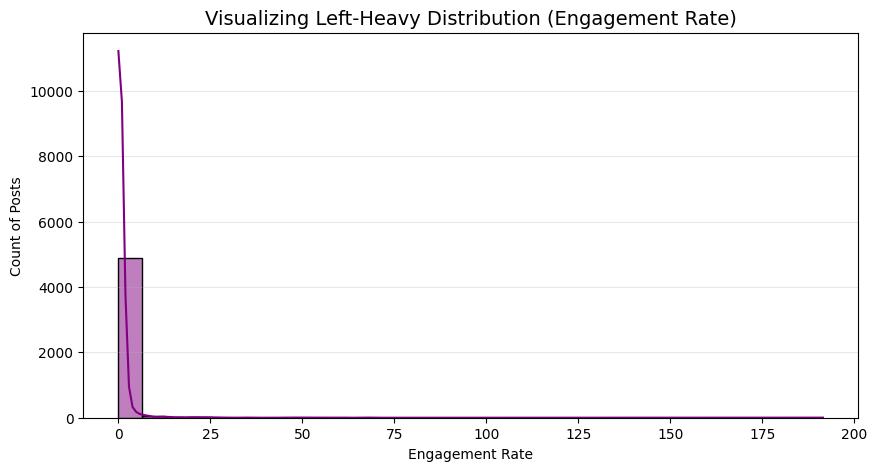

In [30]:
# 2. COLAB VISUALIZATION: Plotting the highly skewed column to show the professor
plt.figure(figsize=(10, 5))
sns.histplot(df['engagement_rate'], kde=True, color='purple', bins=30)
plt.title('Visualizing Left-Heavy Distribution (Engagement Rate)', fontsize=14)
plt.xlabel('Engagement Rate')
plt.ylabel('Count of Posts')
plt.grid(axis='y', alpha=0.3)
plt.show()

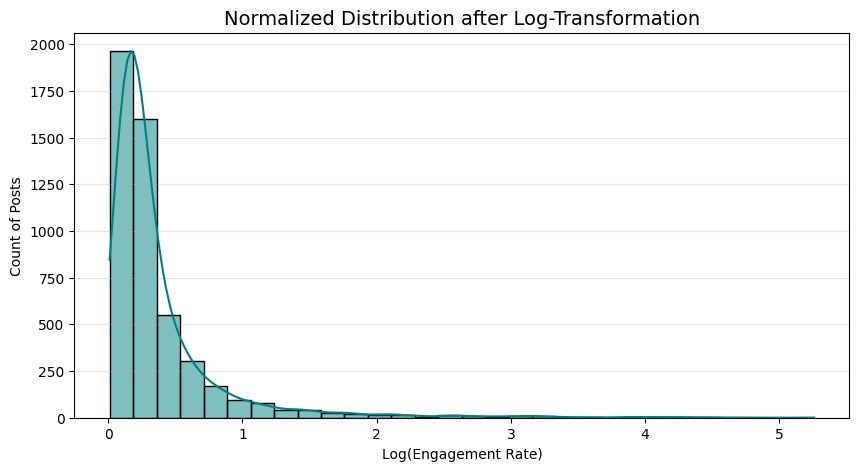

In [31]:
# 3. Visualizing how Log Transformation completely fixes the distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['engagement_rate_log'], kde=True, color='teal', bins=30)
plt.title('Normalized Distribution after Log-Transformation', fontsize=14)
plt.xlabel('Log(Engagement Rate)')
plt.ylabel('Count of Posts')
plt.grid(axis='y', alpha=0.3)
plt.show()

# **Data Visualization**

## **Matplotlib**

In [42]:
plt.rcParams['figure.figsize'] = (10, 8)
df = df.sort_values('posted_at') # Date is sorted for the line chart calculation

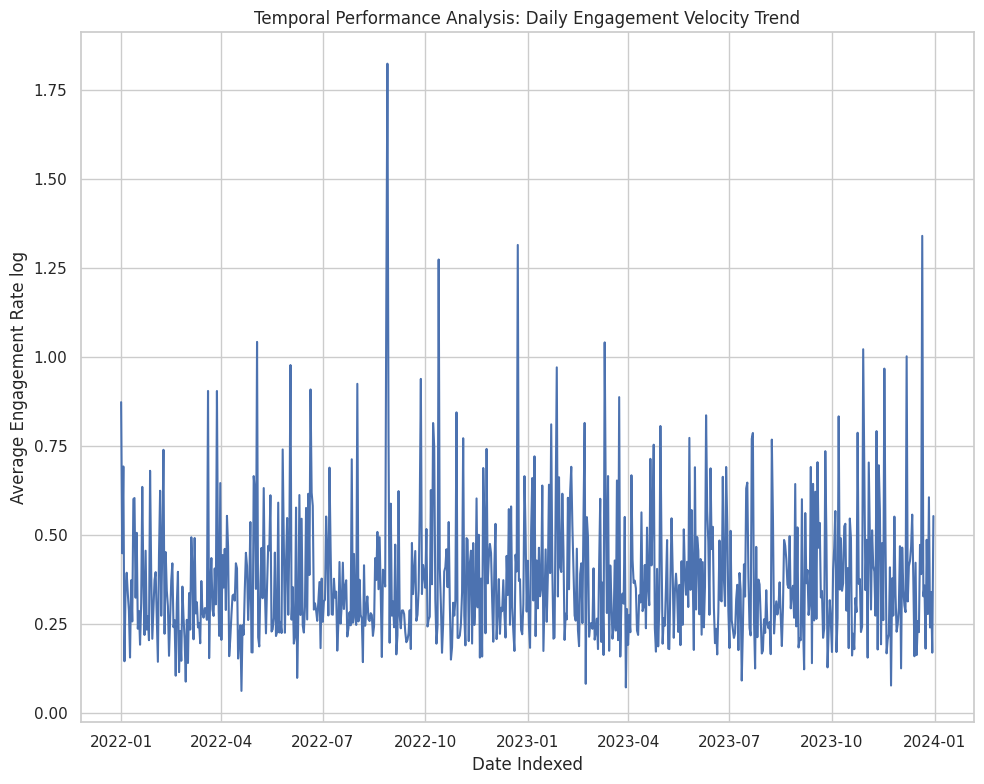

In [43]:
# Line Chart (Daily Engagement Trend)

plt.figure()
# Grouping data by date index to generate a clean daily metric aggregation
daily_trend = df.groupby(df['posted_at'].dt.date)['engagement_rate_log'].mean().reset_index()
daily_trend['posted_at'] = pd.to_datetime(daily_trend['posted_at'])
plt.plot(daily_trend['posted_at'],daily_trend['engagement_rate_log'])
plt.title('Temporal Performance Analysis: Daily Engagement Velocity Trend')
plt.xlabel('Date Indexed')
plt.ylabel('Average Engagement Rate log')
plt.tight_layout()
plt.show()

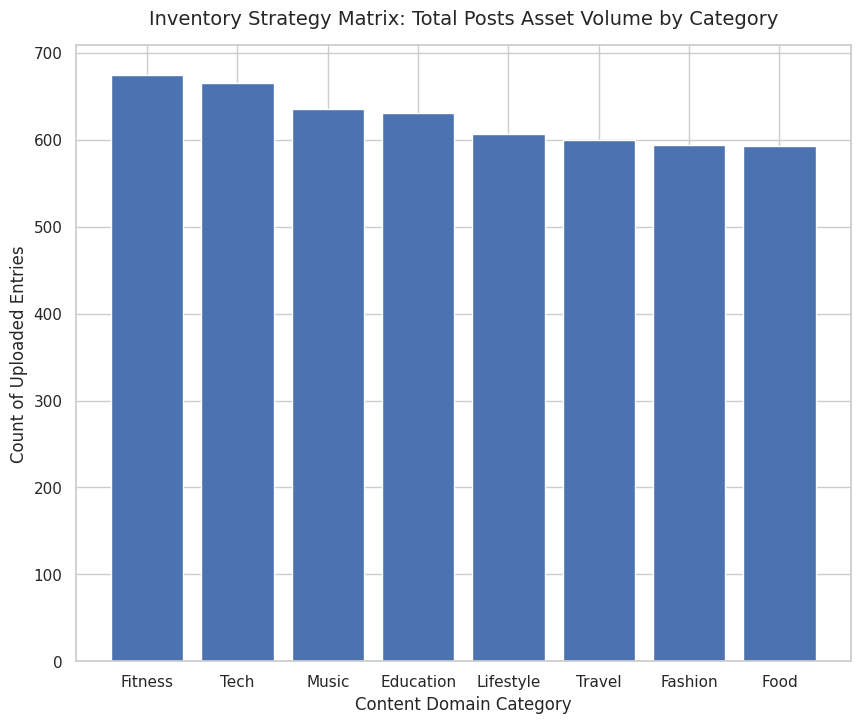

In [44]:
# Bar Chart (Posts by Category)

plt.figure()
# Value counts sorted to present structured visual volume bars
category_counts = df['post_category'].value_counts().reset_index()
category_counts.columns = ['Category', 'Volume']
num_bars = len(category_counts)
plt.bar(category_counts['Category'], category_counts['Volume'])
plt.title('Inventory Strategy Matrix: Total Posts Asset Volume by Category', fontsize=14, pad=15)
plt.xlabel('Content Domain Category')
plt.ylabel('Count of Uploaded Entries')
plt.show()

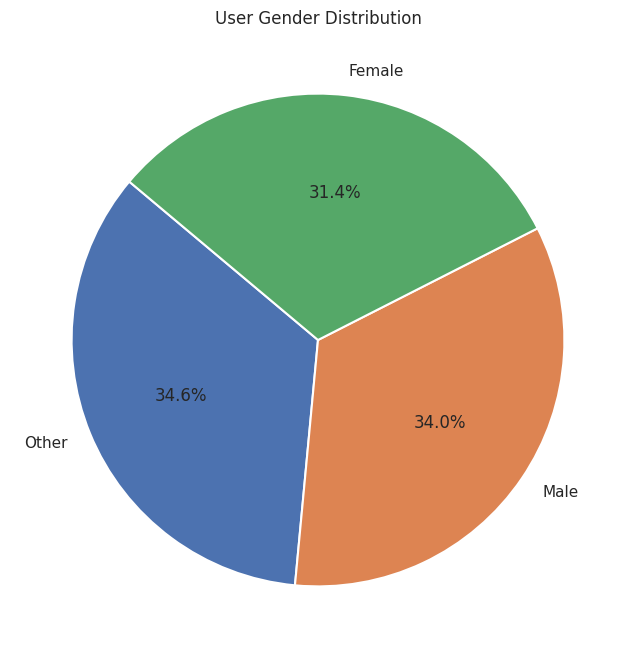

In [45]:
# Pie Chart: Gender Distribution

gender_data = df['gender'].value_counts()
plt.pie(gender_data, labels=gender_data.index, autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'antialiased': True})
plt.title('User Gender Distribution')
plt.show()

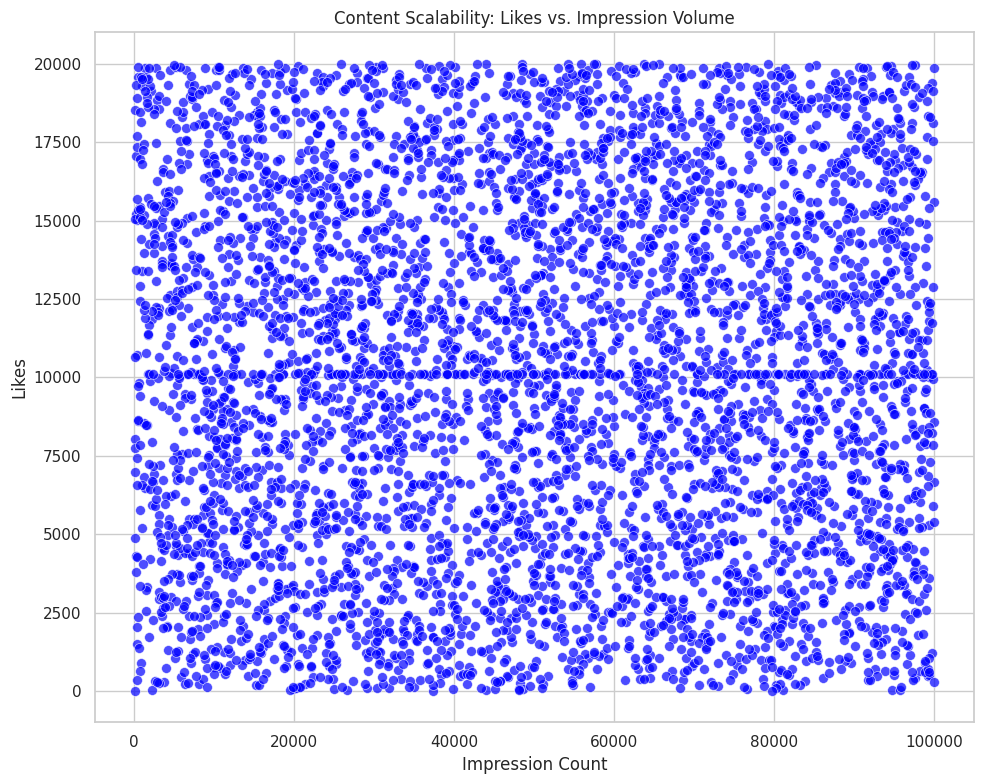

In [46]:
# Scatter: likes vs impressions

plt.scatter(df['impression_count'], df['likes'], color='blue', alpha=0.7, edgecolor='white', linewidth=0.5, s=50)
plt.title('Content Scalability: Likes vs. Impression Volume')
plt.xlabel('Impression Count')
plt.ylabel('Likes')
plt.tight_layout()
plt.show()

##**Seaborn**

In [47]:
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")

<Figure size 1000x800 with 0 Axes>

/tmp/ipykernel_629/3018899029.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot( data = df,


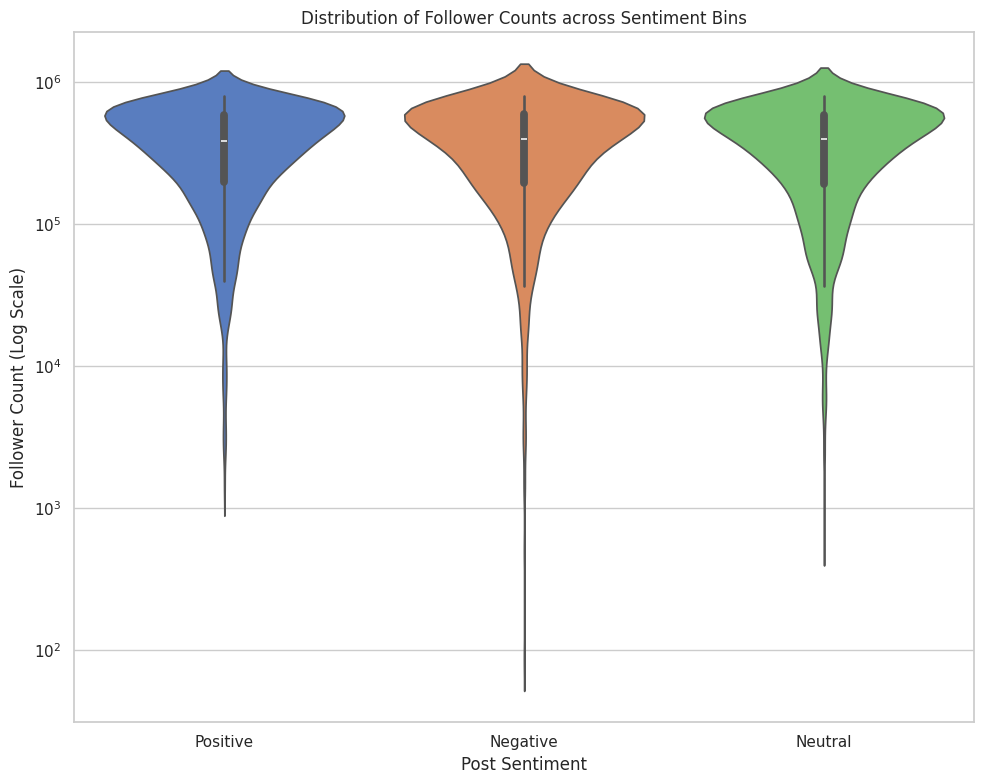

In [48]:
# Violin: followers vs sentiment

ax = sns.violinplot( data = df,
                    x = 'sentiment',
                    y = 'follower_count',
                    order = ['Positive','Negative','Neutral'],
                     palette = 'muted',
                     inner = 'box',
                     log_scale = True)
plt.title('Distribution of Follower Counts across Sentiment Bins')
plt.xlabel('Post Sentiment')
plt.ylabel('Follower Count (Log Scale)')
plt.tight_layout()
plt.show()

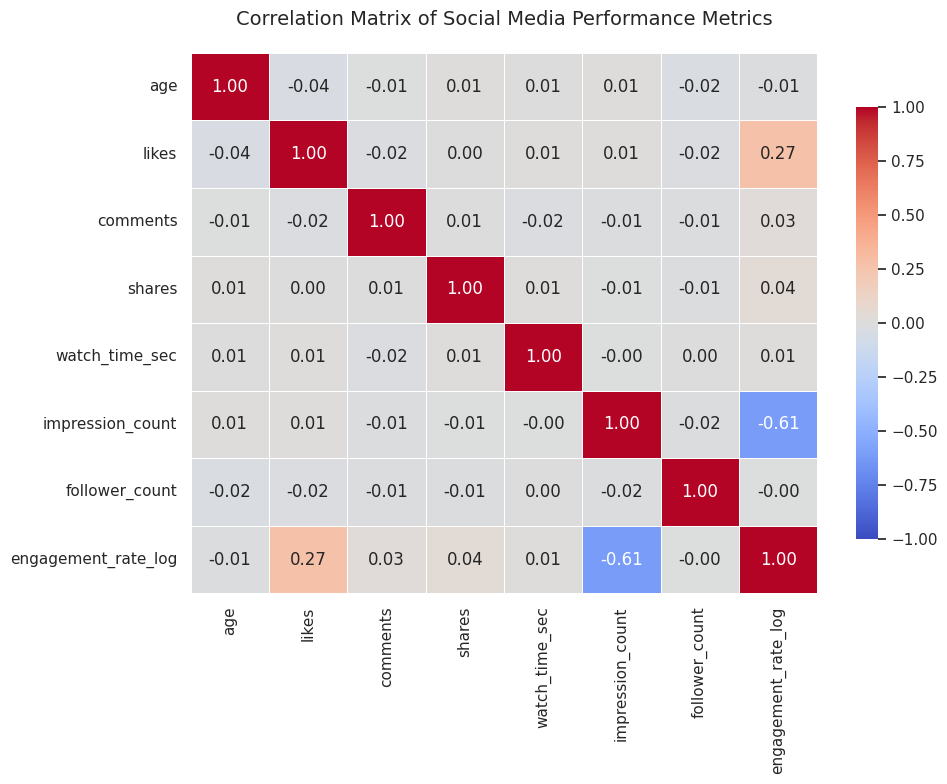

In [49]:
# Heatmap: correlation matrix

numerical_cols_1 = [
    'age', 'likes', 'comments', 'shares',
    'watch_time_sec', 'impression_count',
    'follower_count', 'engagement_rate_log'
]
df_num = df[numerical_cols_1].apply(pd.to_numeric, errors='coerce')
corr_matrix = df_num.corr()

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',            # Distinct Blue (Negative) to Red (Positive) gradient
    vmax=1.0, vmin=-1.0,        # Standard correlation bounds [-1, 1]
    center=0,                   # Pure white marks a perfect neutral 0.0 correlation
    annot=True,                 # Prints the exact correlation coefficient on each cell
    fmt=".2f",                  # Standardizes text numbers to 2 decimal points
    linewidths=0.5,             # Subtle white grid separation borders
    cbar_kws={"shrink": .8}     # Fits color legend nicely next to the chart
)
plt.title('Correlation Matrix of Social Media Performance Metrics', fontsize=14, pad=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

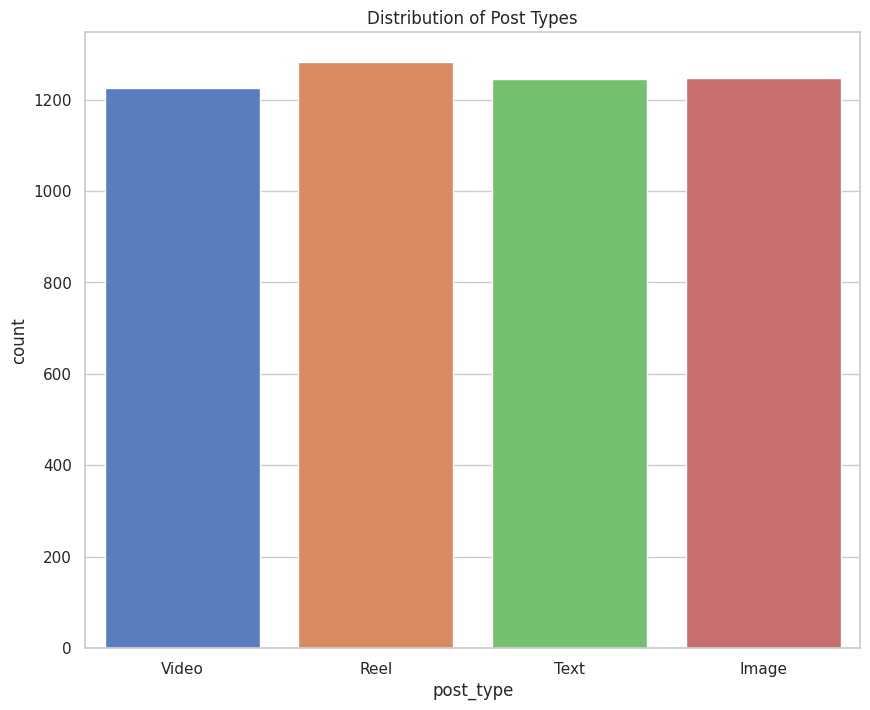

In [59]:
# Count plot: post type

sns.countplot(data=df, x='post_type', hue='post_type', palette='muted', legend=False)
plt.title('Distribution of Post Types')
plt.show()

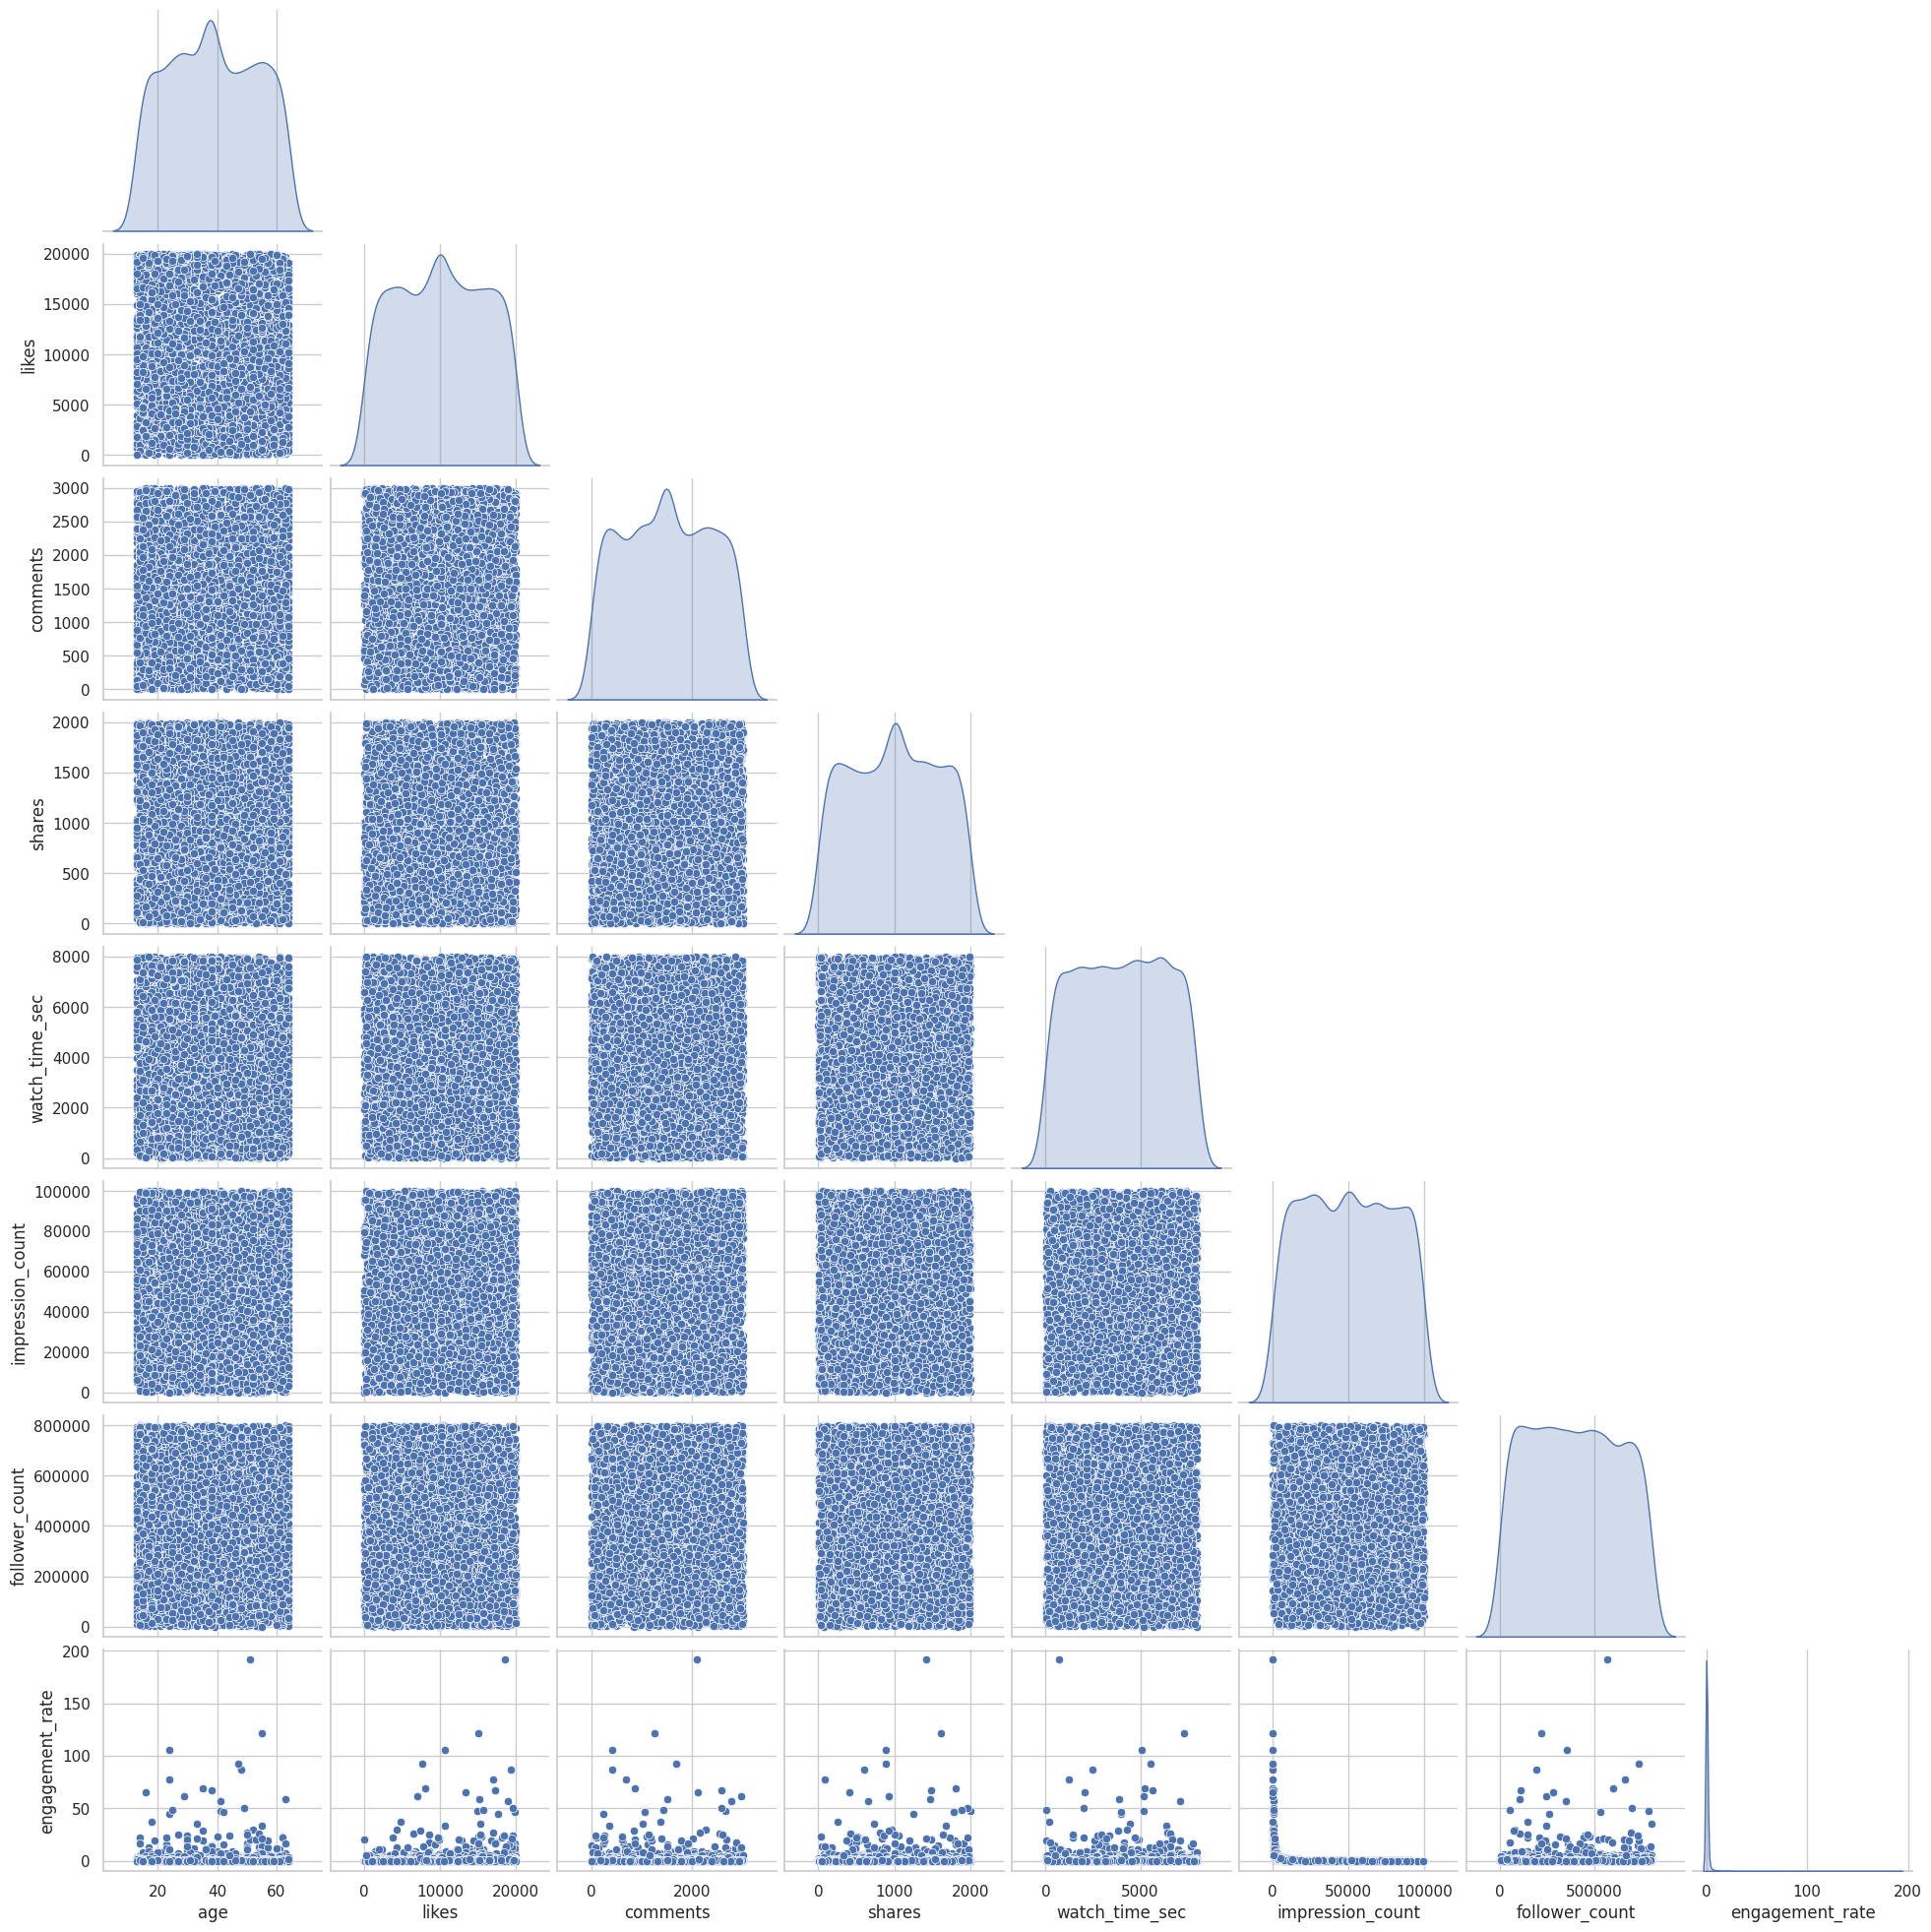

In [60]:
# Pair plot: numeric features

sns.pairplot(df[numeric_cols], diag_kind='kde', corner=True)
plt.show()

#**Final Insights**

**Final Business Insights**

- **Post type**: Identify the post type with the highest average engagement rate.
- **Content category**: Identify the category with the highest average engagement rate.
- **Country**: Identify the country with the highest average engagement rate.
User Trends
- **Age**: Describe which age group has the highest average engagement and whether the age–engagement correlation is weak, moderate, or strong based on the calculated correlation.
- **Verification**: Compare verified and non-verified accounts using average engagement rate, impressions, and watch time.
Behavioral Insights
- **Time of day**: The current dataset cannot support this analysis because posted_at contains dates but no time-of-day information. Do not claim a best hour unless an hour field is added.
- **Device**: Identify the device with the highest average watch time and compare it with the other devices.
Sentiment Analysis
- **Best sentiment**: Identify the sentiment with the highest average engagement rate.
- **Negative vs neutral**: Compare their average engagement rate, impressions, and watch time to describe how negative and neutral posts behave.
Analytical note: These are observational relationships in the dataset; they show differences/associations rather than proving that one factor causes engagement to increase or decrease.